# DE Tech Adoption Radar — 커리큘럼 인텔리전스 (W2M5)

**채용 공고(선행 신호)의 기술어휘 빈도 = 어떤 스택을 가르쳐야 취업하는가.**
국내 부트캠프 커리큘럼 기획자를 위해, "채용시장이 뜨겁기 6~12개월 전에" 두 결정을 지원한다:

1. **어떤 직무를 타겟으로 기수를 열까?** → *분기별 기술 수요 추이* (2025-Q4 → 2026-Q1 → 2026-Q2)
2. **그 직무 트랙에서 뭘 가르칠까?** → *직무별 기술 스택* (데이터 엔지니어링·백엔드·ML/AI·데이터 분석 …)

> 파이프라인: **Extract**(채용 공고 웹 스크래핑) → **Transform**(직무 분류 + 기술어휘 매칭 + 분기 버킷) → **Load**(SQLite) → **Word Cloud 렌더**.
> 데이터는 국내(KR) 28개사 + 미국(US) 35개사. 비치헤드는 국내 채용 신호(취업률이 걸린 시장).

In [1]:
%matplotlib inline
import pandas as pd

from scrape_signals import extract
from analyze import run as etl_run, crawl_summary
from render import (
    load_mentions, load_granular, pick_momentum_quarters,
    category_techstack, view_quarterly, view_by_category,      # ← 커리큘럼 헤드라인 뷰
    view_crawl_volume, view_mindshare, view_us_vs_kr, view_momentum,
    view_competitor_bar, view_granular_bar, view_stack_profile,
)

## 1. Extract — 채용 공고 **웹 스크래핑**
Greenhouse 공개 임베드 HTML 보드 · 그리팅(greetinghr) SSR · 개별 채용페이지(Ashby).
멱등적 캐시(`data/raw/*.json`) — 있으면 재사용, `extract(force=True)`로 강제 재수집.
국내(KR) 세그먼트를 그리팅 회사 10곳 추가로 심화했다(비치헤드 신호원).

In [2]:
tokens = extract()          # 캐시에 없는 회사만 스크래핑(신규 KR 포함). 전체 재수집: extract(force=True)
print("수집 성공 회사 수:", len(tokens))

2026-07-07-17-33-37, [START-Extract] 채용 공고 웹 스크래핑 시작. 대상 63개사 (force=False)
2026-07-07-17-33-37, [CACHE-Extract] Coupang[KR]: 캐시 사용 (641건)
2026-07-07-17-33-37, [CACHE-Extract] Danggeun[KR]: 캐시 사용 (39건)
2026-07-07-17-33-37, [CACHE-Extract] Moloco[KR]: 캐시 사용 (47건)
2026-07-07-17-33-37, [CACHE-Extract] Sendbird[KR]: 캐시 사용 (18건)
2026-07-07-17-33-37, [CACHE-Extract] Krafton[KR]: 캐시 사용 (65건)
2026-07-07-17-33-37, [CACHE-Extract] Olive Young[KR]: 캐시 사용 (196건)
2026-07-07-17-33-37, [CACHE-Extract] Musinsa[KR]: 캐시 사용 (159건)
2026-07-07-17-33-37, [CACHE-Extract] Kurly[KR]: 캐시 사용 (67건)
2026-07-07-17-33-37, [CACHE-Extract] Team Sparta[KR]: 캐시 사용 (26건)
2026-07-07-17-33-37, [CACHE-Extract] Idus[KR]: 캐시 사용 (24건)
2026-07-07-17-33-37, [CACHE-Extract] 111Percent[KR]: 캐시 사용 (23건)
2026-07-07-17-33-37, [CACHE-Extract] MyRealTrip[KR]: 캐시 사용 (20건)
2026-07-07-17-33-37, [CACHE-Extract] Wadiz[KR]: 캐시 사용 (16건)
2026-07-07-17-33-37, [CACHE-Extract] W Concept[KR]: 캐시 사용 (13건)
2026-07-07-17-33-37, [CACHE-Extract] Gravit

## 2. Transform + Load — 직무 분류 · 기술어휘 매칭 · SQLite 적재
제목(title)으로 **직무(category)**를 분류하고, 기술직 공고 본문에서 기술 토큰을 매칭(job-level presence).
`first_published` → 분기(YYYY-Qn) 버킷. 결과를 `data/radar.db`의 jobs/mentions/granular_mentions에 적재.

In [3]:
jobs_df, mentions_df, granular_df = etl_run()
print("jobs=%d | 기술직=%d | mentions=%d | granular=%d\n"
      % (len(jobs_df), int(jobs_df.is_tech_role.sum()), len(mentions_df), len(granular_df)))

print("[직무(category)별 기술언급 분포]")
display(mentions_df.groupby(["category", "country"]).size().unstack(fill_value=0))

print("\n[분기 × 국가 기술언급 분포]")
q3 = mentions_df[mentions_df.quarter.isin(["2025-Q4", "2026-Q1", "2026-Q2"])]
display(q3.groupby(["quarter", "country"]).size().unstack(fill_value=0))

2026-07-07-17-33-37, [START-Transform] 직무 필터 + 기술어휘/세분제품 매칭 시작
2026-07-07-17-33-38, [END-Transform] 직무 4406건(기술직 947건) → 기술언급 2349건 · 세분제품 256건 추출
2026-07-07-17-33-38, [START-Load] SQLite 적재 시작 → radar.db
2026-07-07-17-33-38, [END-Load] 적재 완료. jobs=4406, mentions=2349, granular=256
jobs=4406 | 기술직=947 | mentions=2349 | granular=256

[직무(category)별 기술언급 분포]


country,KR,US
category,,
DevOps/인프라/SRE,54,141
ML/AI 엔지니어링,70,243
기타 기술직,88,725
데이터 분석/사이언스,48,145
데이터 엔지니어링,102,320
모바일,0,2
백엔드,216,177
프론트엔드,16,2



[분기 × 국가 기술언급 분포]


country,KR,US
quarter,,
2025-Q4,74,113
2026-Q1,63,379
2026-Q2,343,983


## 2-1. 국가별 크롤링 규모 (KR vs US)

,회사수,원본공고,기술직공고,기술언급,세분제품언급
country,,,,,
KR,28,1612,301,594,85
US,35,2794,646,1755,171
합계,63,4406,947,2349,256


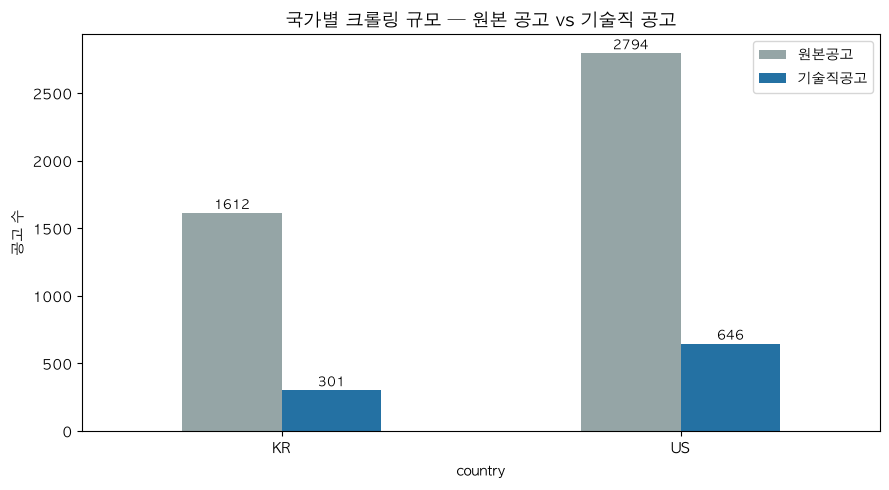

In [4]:
summary = crawl_summary()
display(summary)
fig, _ = view_crawl_volume(summary)

---
# 핵심 산출물 A — 직무별 테크스택 딕셔너리 ("뭘 가르칠까")
직무(category)별로 채용 공고에서 가장 많이 요구되는 기술 스택. **이 표가 곧 트랙별 커리큘럼 후보 목록**이다.
(사용자 결정에 따라 기본 언어 Python/SQL/Java 등을 **제외하지 않고 포함**한다.)

In [5]:
m = load_mentions()
stack = category_techstack(m, top=12)          # {직무: {tech: count}}  (기본 언어 포함)
rows = []
for cat, techs in stack.items():
    top = ", ".join("%s(%d)" % (t, n) for t, n in techs.items())
    rows.append({"직무": cat, "기술언급수": sum(techs.values()), "상위 기술 스택(빈도)": top})
stack_table = pd.DataFrame(rows)
display(stack_table)

,직무,기술언급수,상위 기술 스택(빈도)
0,기타 기술직,636,"Python(124), AWS(100), Kubernetes(62), Postgre..."
1,데이터 엔지니어링,301,"Python(44), SQL(42), Airflow(40), Snowflake(28..."
2,백엔드,340,"AWS(56), Java(51), Kubernetes(46), Python(37),..."
3,ML/AI 엔지니어링,221,"Python(45), PyTorch(26), Spark(21), SQL(21), T..."
4,DevOps/인프라/SRE,185,"AWS(40), Kubernetes(32), GCP(24), Python(21), ..."
5,데이터 분석/사이언스,190,"SQL(64), Python(60), Snowflake(15), BigQuery(1..."
6,프론트엔드,18,"AWS(6), Docker(3), Kubernetes(1), Java(1), Pyt..."
7,모바일,2,"SQL(1), Python(1)"


### 🔎 가중 렌즈 — 직무 *차별* 기술 (recency · breadth · lift)
원본 빈도는 Python/SQL로 쏠린다. 가중 렌즈는 **① 최신 분기↑(recency) · ② 회사당 1회(breadth, 대형사 편중 제거) · ③ 그 직무에 특징적인 기술↑(lift)**로 보정 → **"이 트랙을 *차별화*하는 스택"**이 드러난다. (손튜닝 아님 — 세 가중 모두 원칙 기반, 원본과 병행 제시)

In [6]:
m = load_mentions()
w_stack = category_techstack(m, top=12, weighted=True)   # recency·breadth·lift
rows = []
for cat, techs in w_stack.items():
    top = ", ".join("%s(%.1f)" % (t, float(s)) for t, s in techs.items())
    rows.append({"직무": cat, "상위 *차별* 기술 (가중점수)": top})
display(pd.DataFrame(rows))

,직무,상위 *차별* 기술 (가중점수)
0,기타 기술직,"Kubernetes(13.9), Terraform(13.7), Java(13.3),..."
1,데이터 엔지니어링,"Flink(21.6), Redshift(19.2), Airflow(18.8), Da..."
2,백엔드,"Redis(15.3), Java(14.1), MySQL(11.7), AWS(11.6..."
3,ML/AI 엔지니어링,"PyTorch(23.9), TensorFlow(16.5), Ray(9.6), MLf..."
4,DevOps/인프라/SRE,"Terraform(25.6), Kubernetes(18.3), GCP(17.4), ..."
5,데이터 분석/사이언스,"SQL(34.7), dbt(16.0), Python(14.2), BigQuery(1..."
6,프론트엔드,"AWS(6.3), Docker(0.6), Kubernetes(0.6), SQL(0...."
7,모바일,"Python(0.1), SQL(0.1)"


---
# 핵심 산출물 B — 분기별 기술 수요 추이 ("어떤 직무/기술을 타겟?")
행=분기(2025-Q4 → 2026-Q1 → 2026-Q2), 열=국가(KR·US 나란히). 개강 때 어떤 기술이 떠오르는지의 **선행 신호**.

> ⚠️ 분기는 *현재 열린 공고의 게시 분기* 기준이라 과거 분기(2025-Q4)는 표본이 얇다 → **방향성 지표**로 읽는다.

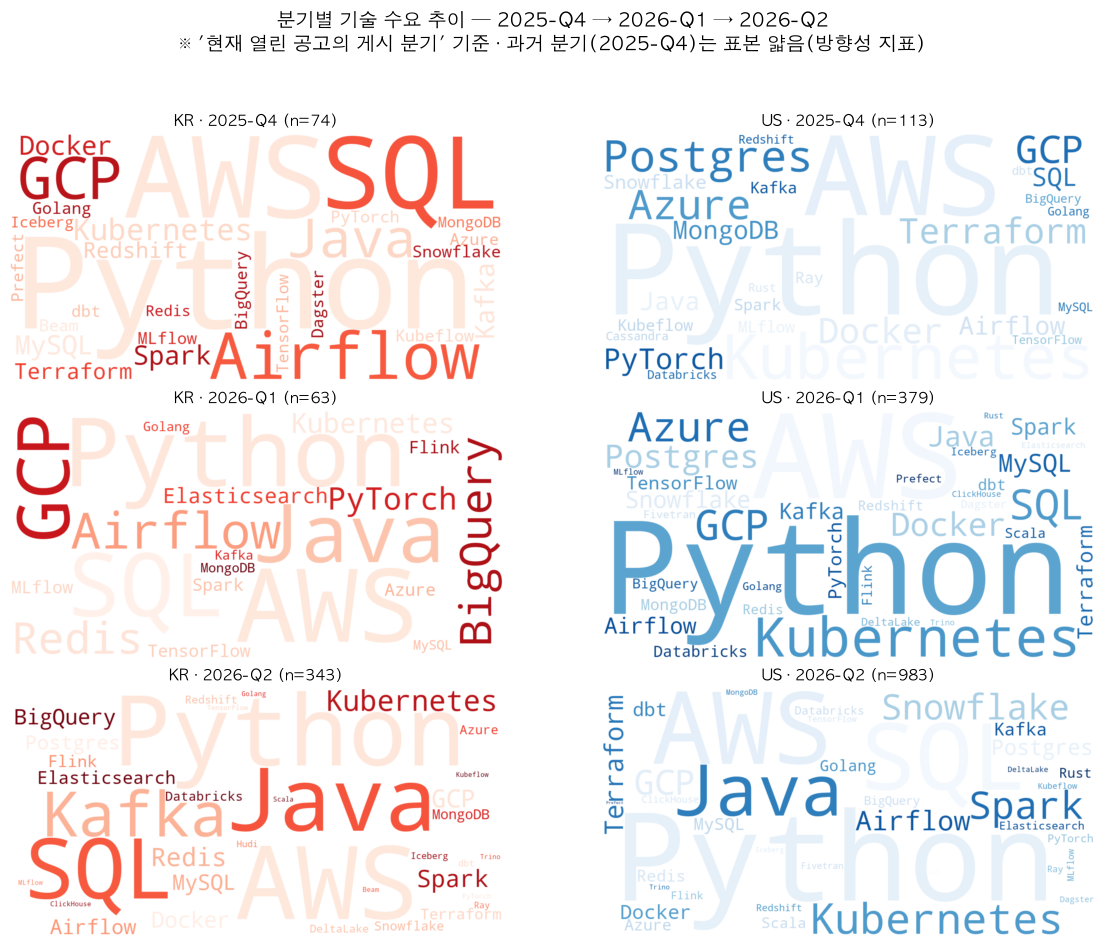

In [7]:
m = load_mentions()
fig, _ = view_quarterly(m)          # 3분기 × (KR, US) 워드클라우드 격자

### 🔎 가중 렌즈 — 분기별 (회사 breadth × 차별성 lift)
※ recency는 셀이 이미 단일 분기라 within-cell no-op. **breadth**로 대형 채용사 편중을 제거하고, **lift**로 그 분기에 상대적으로 두드러진 기술을 부각한다.

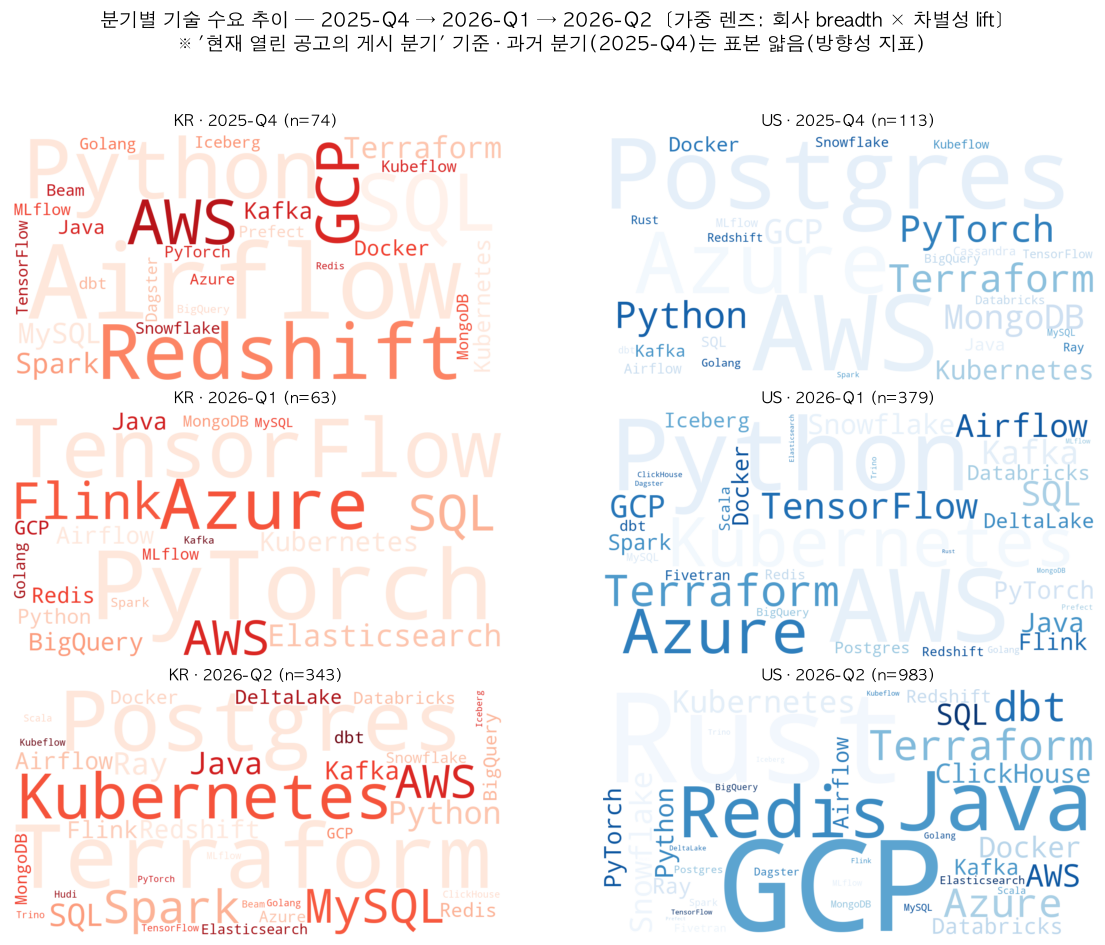

In [8]:
m = load_mentions()
fig, _ = view_quarterly(m, weighted=True)

---
# 핵심 산출물 C — 직무별 기술 스택 워드클라우드 ("뭘 가르칠까")
행=직무, 열=국가(KR·US 나란히). **KR에 있는 기술=필수 코어(취업 위해) / US에만 있는 기술=선점 트랙 후보.**

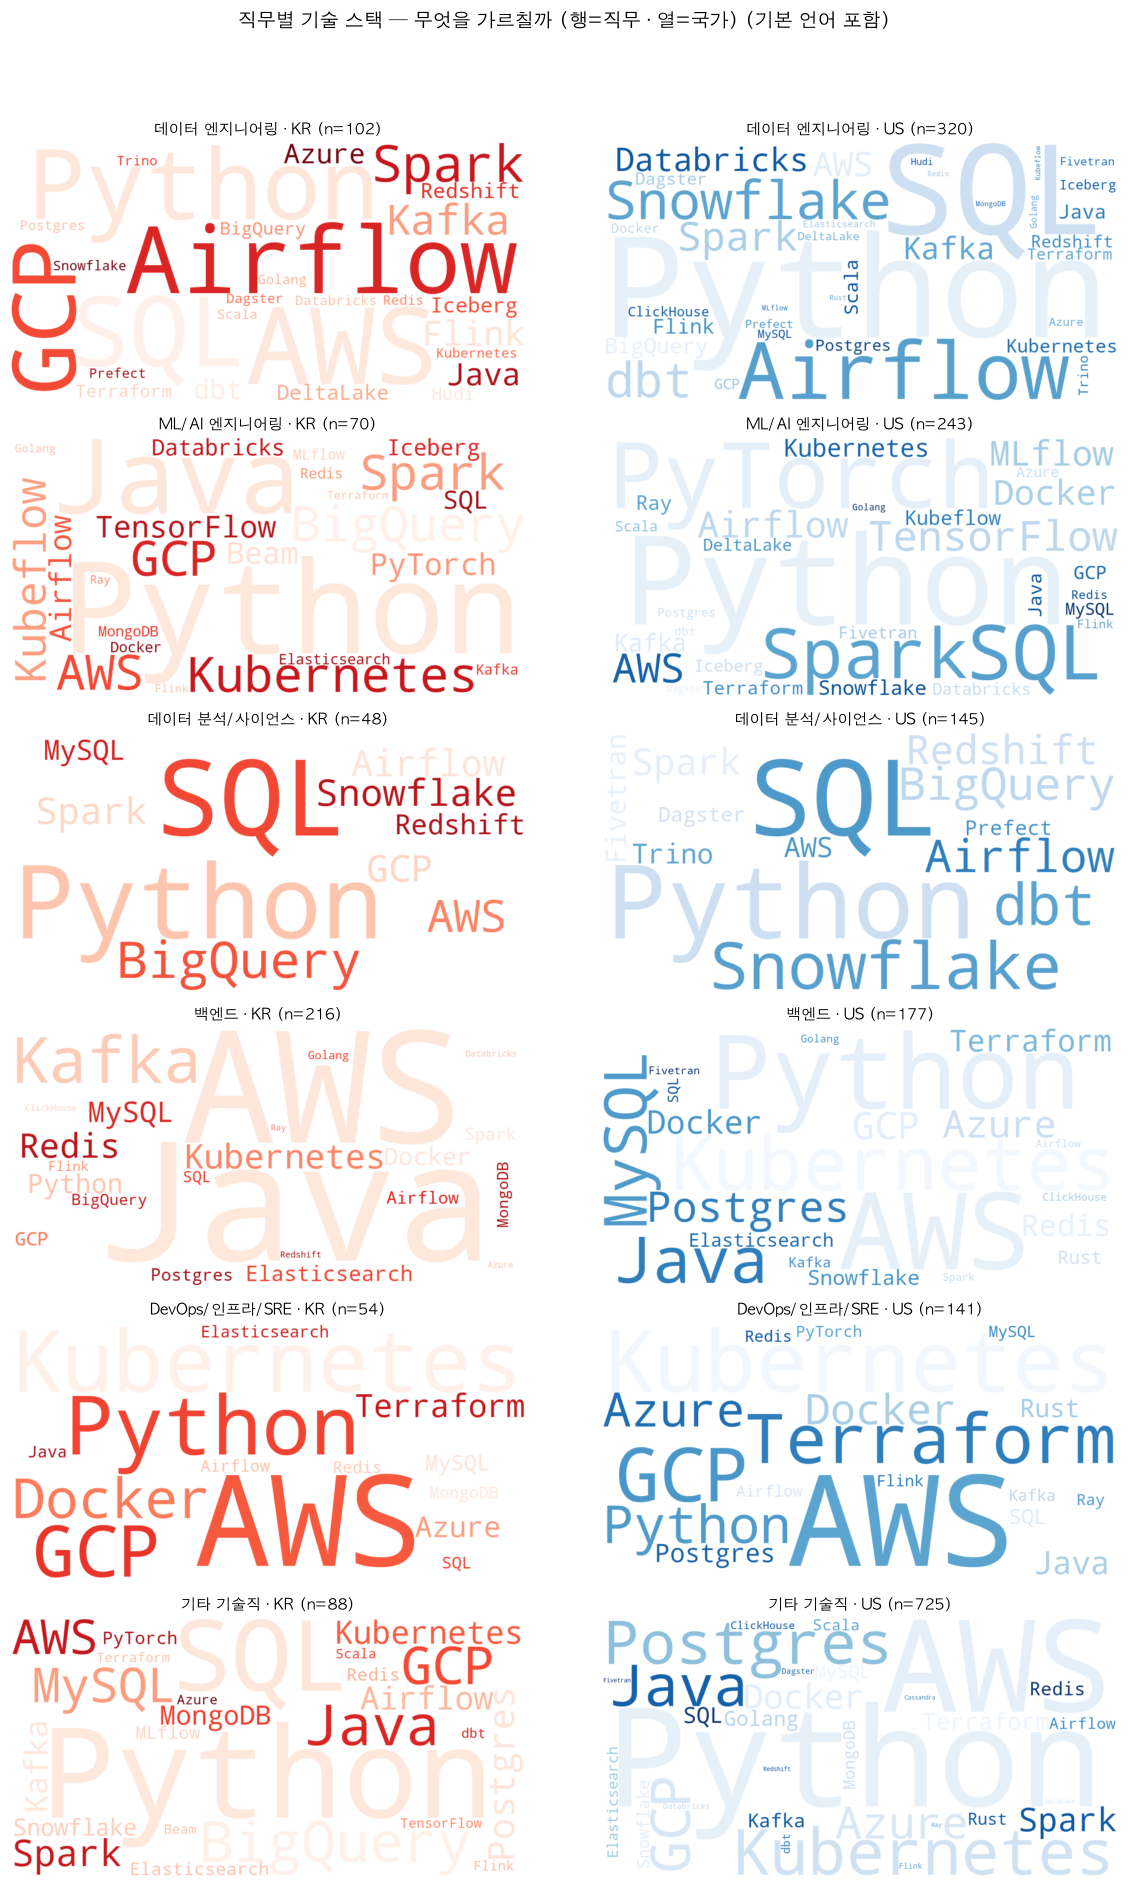

In [9]:
m = load_mentions()
fig, _ = view_by_category(m)        # 직무 × (KR, US) 워드클라우드 격자

### 🔎 가중 렌즈 — 직무별 (recency · breadth · lift)
각 직무 *고유*의 스택이 원본보다 뚜렷해진다(Python/AWS는 자연히 축소). **KR 열 = 필수 코어(취업 위해) / US 열 = 국내 선점 후보** 판단에 쓴다.

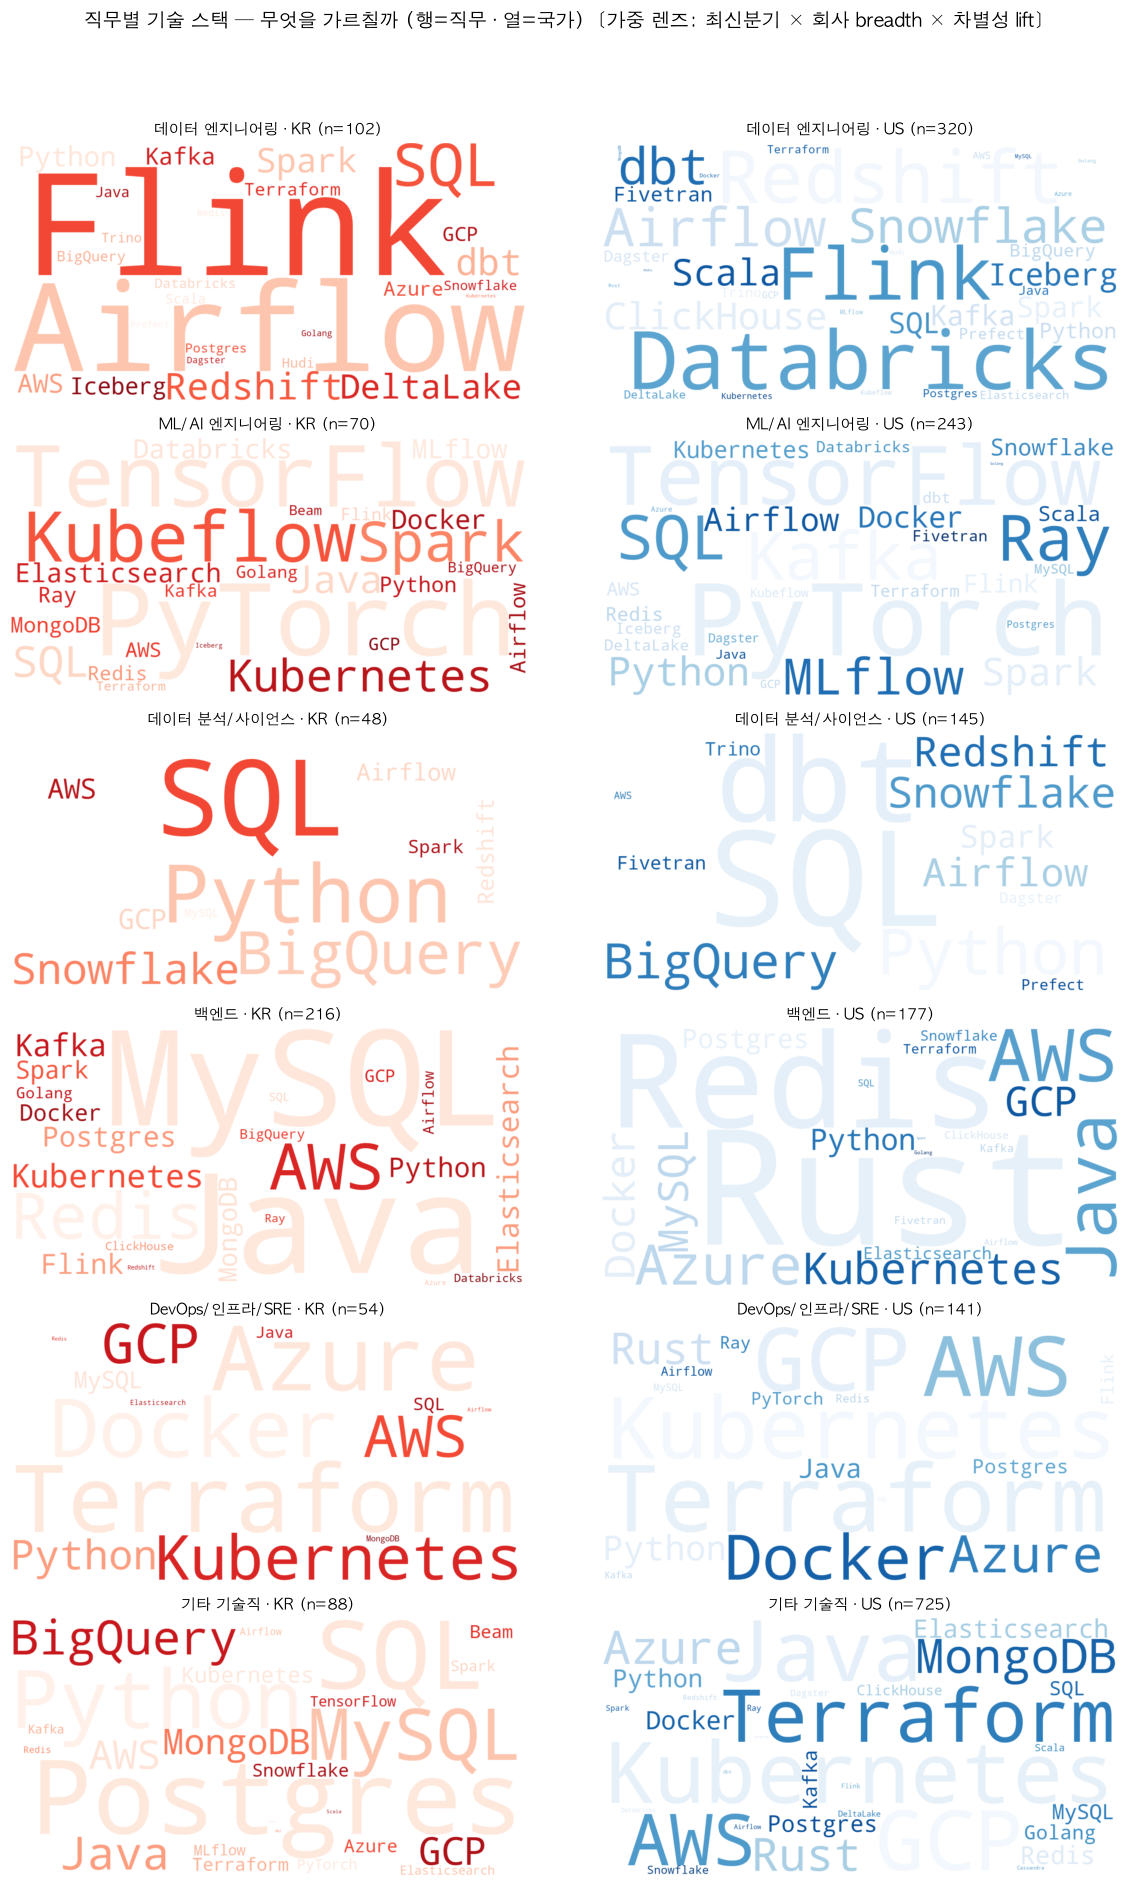

In [10]:
m = load_mentions()
fig, _ = view_by_category(m, weighted=True)

---
## 보조 뷰 1 — DE 기술 마인드셰어 (전체, 범용 기술 제외)

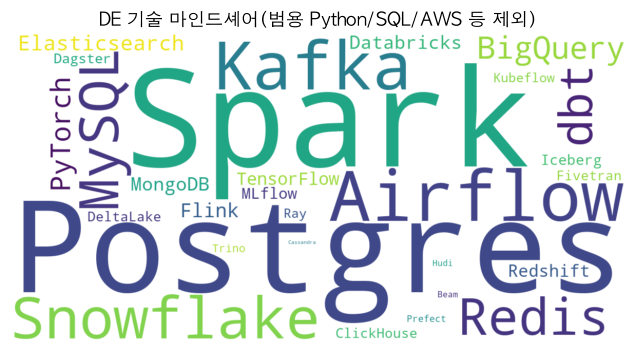

In [11]:
m = load_mentions()
fig, _ = view_mindshare(m)

## 보조 뷰 2 — US vs KR 비교 (범용 기술 제외)

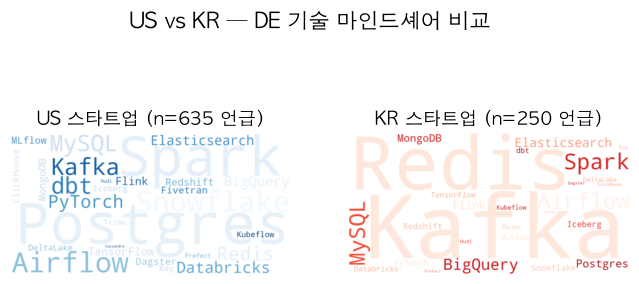

In [12]:
m = load_mentions()
fig, _ = view_us_vs_kr(m)

## 보조 뷰 3 — 모멘텀 델타 (추이, 상승=빨강/하락=파랑)

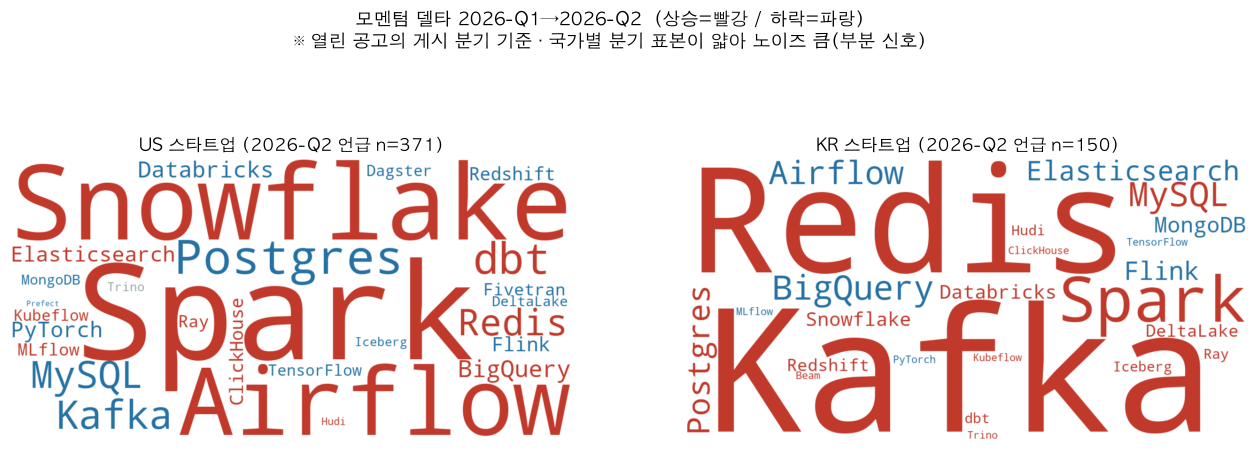

In [13]:
m = load_mentions()
qe, ql = pick_momentum_quarters(m)   # 진행중 부분 분기 제외
fig, _ = view_momentum(m, qe, ql)

## 보조 뷰 4 — 경쟁 마인드셰어 (데이터 웨어하우스)

country,KR,US
tech,,
Snowflake,8.4,36.5
Databricks,6.7,10.3
BigQuery,35.4,9.7
Redshift,8.4,7.4
Synapse,0.0,0.0


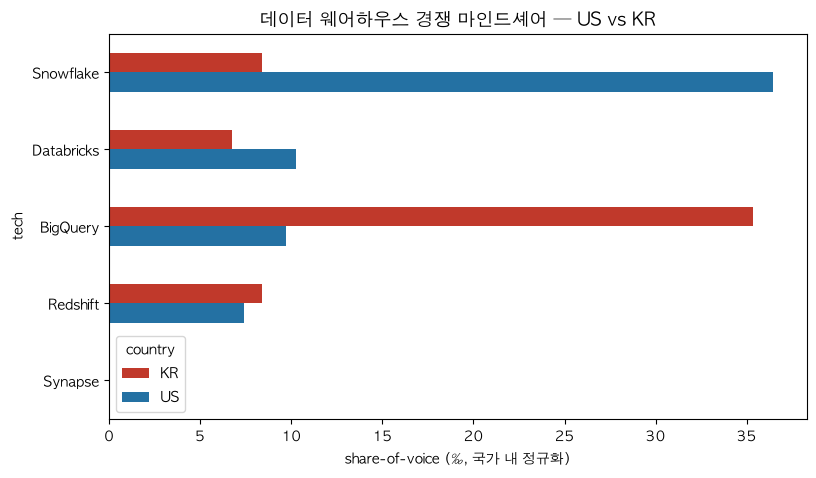

In [14]:
m = load_mentions()
fig, df = view_competitor_bar(m)
display(df.round(1))

## 보조 뷰 5 — 세분 제품 마인드셰어 (Redshift·Snowpark 수준)

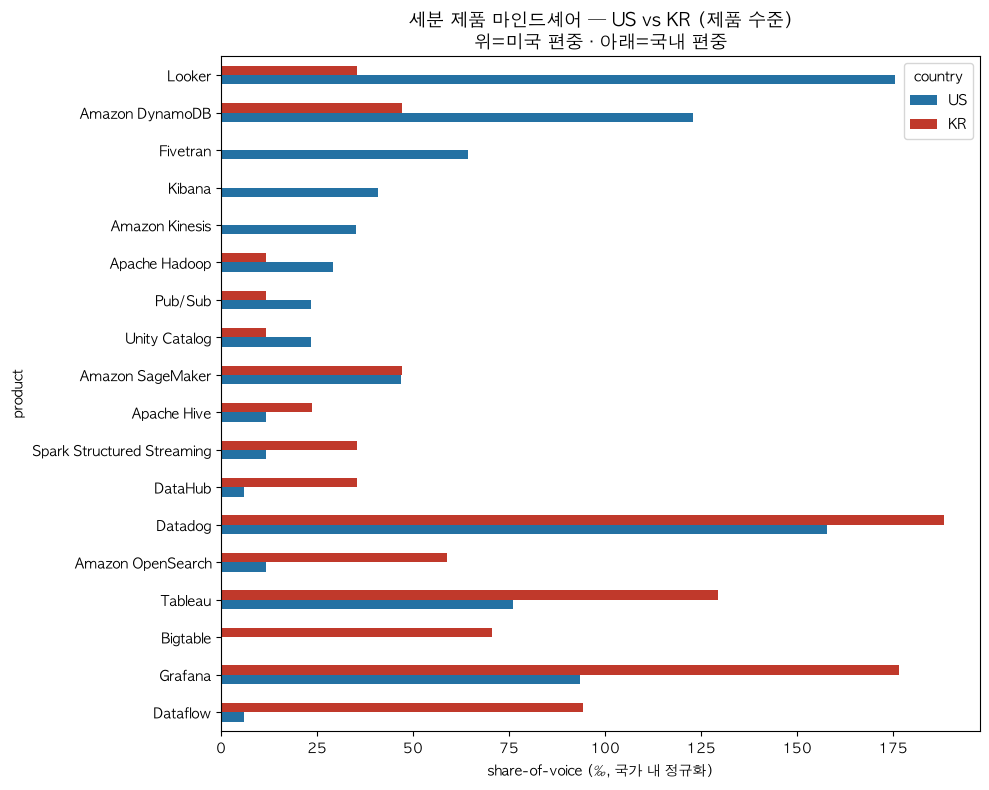

In [15]:
g = load_granular()
fig, _ = view_granular_bar(g)

## 보조 뷰 6 — 스택 성숙도 KPI (모던 데이터 스택 vs 레거시 Hadoop)

,모던 데이터 스택,레거시 Hadoop
country,,
US,12.9,4.1
KR,5.9,3.5


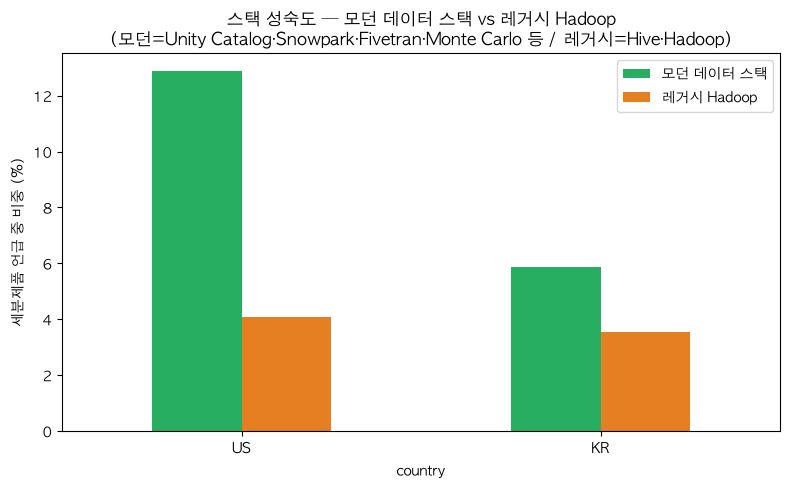

In [16]:
g = load_granular()
fig, prof = view_stack_profile(g)
display(prof.round(1))

---
## 결론 — 커리큘럼 킬러 메시지
- **필수 코어(취업률 방어):** KR 채용에 크게 뜨는 기술을 트랙 코어로. (산출물 A·C의 KR 열)
- **선점 트랙(선행 신호):** US엔 뜨겁지만 KR엔 아직 없는 기술 = 다음 기수 선점 후보. (산출물 B·C의 US vs KR 갭)
- **타겟 직무:** 산출물 A의 직무별 언급수 + B의 분기 추이로 "이번 기수에 어떤 직무를 열지" 결정.

> Udemy Marketplace Insights(학습자 검색=후행)조차 못 주는 **채용 선행 신호(6~12개월 앞)**가 이 도구의 10x 차별점.